<a href="https://colab.research.google.com/github/AngelTroncoso/AprendizajeAutomatico/blob/main/AnalisisModelosenTiemposDeOsio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Regresion Lineal

In [13]:
from google.colab import drive
drive.mount('/content/drive')
# Example usage:
# Assuming your file is in 'My Drive/data' folder in Google Drive
file_path = '/content/adult.csv' # Replace with your file path

import pandas as pd

try:
  df = pd.read_csv(file_path) # Or pd.read_excel(), etc. based on file type
  print(df.head()) # Display the first few rows of the DataFrame
except FileNotFoundError:
  print(f"Error: File not found at {file_path}")
except Exception as e:
  print(f"An error occurred: {e}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   age         workclass  fnlwgt  education  education-num  \
0    2         State-gov   77516  Bachelors             13   
1    3  Self-emp-not-inc   83311  Bachelors             13   
2    2           Private  215646    HS-grad              9   
3    3           Private  234721       11th              7   
4    1           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capitalgain  capitalloss  hoursperweek native-coun

In [14]:
from google.colab import drive
import pandas as pd

# #Regresion Lineal
drive.mount('/content/drive')

# Example usage:
# Assuming your file is in 'My Drive/data' folder in Google Drive
file_path = '/content/adult.csv'  # Replace with your file path

try:
    df = pd.read_csv(file_path)  # Or pd.read_excel(), etc. based on file type

    # Spanish column names (replace with actual translations)
    new_column_names = {
        'age': 'edad',
        'workclass': 'clase_trabajo',
        'fnlwgt': 'peso_final',
        'education': 'educacion',
        'education-num': 'educacion_num',
        'marital-status': 'estado_civil',
        'occupation': 'ocupacion',
        'relationship': 'relacion',
        'race': 'raza',
        'sex': 'sexo',
        'capital-gain': 'ganancia_capital',
        'capital-loss': 'perdida_capital',
        'hours-per-week': 'horas_por_semana',
        'native-country': 'pais_natal',
        'income': 'ingresos'
    }

    # Rename columns
    df = df.rename(columns=new_column_names)

    print(df.head())  # Display the first few rows of the DataFrame
except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
except KeyError as e:
    print(f"Error: Column not found: {e}") # Handle potential KeyError if a column name doesn't exist
except Exception as e:
    print(f"An error occurred: {e}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   edad     clase_trabajo  peso_final  educacion  educacion_num  \
0     2         State-gov       77516  Bachelors             13   
1     3  Self-emp-not-inc       83311  Bachelors             13   
2     2           Private      215646    HS-grad              9   
3     3           Private      234721       11th              7   
4     1           Private      338409  Bachelors             13   

         estado_civil          ocupacion       relacion   raza    sexo  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capitalgain  capital

#Análisis Exploratorio EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   edad           48842 non-null  int64 
 1   clase_trabajo  46043 non-null  object
 2   peso_final     48842 non-null  int64 
 3   educacion      48842 non-null  object
 4   educacion_num  48842 non-null  int64 
 5   estado_civil   48842 non-null  object
 6   ocupacion      46033 non-null  object
 7   relacion       48842 non-null  object
 8   raza           48842 non-null  object
 9   sexo           48842 non-null  object
 10  capitalgain    48842 non-null  int64 
 11  capitalloss    48842 non-null  int64 
 12  hoursperweek   48842 non-null  int64 
 13  pais_natal     47985 non-null  object
 14  class          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
None
               edad    peso_final  educacion_num   capitalgain   capitalloss  \
count  48842.000000  4.88

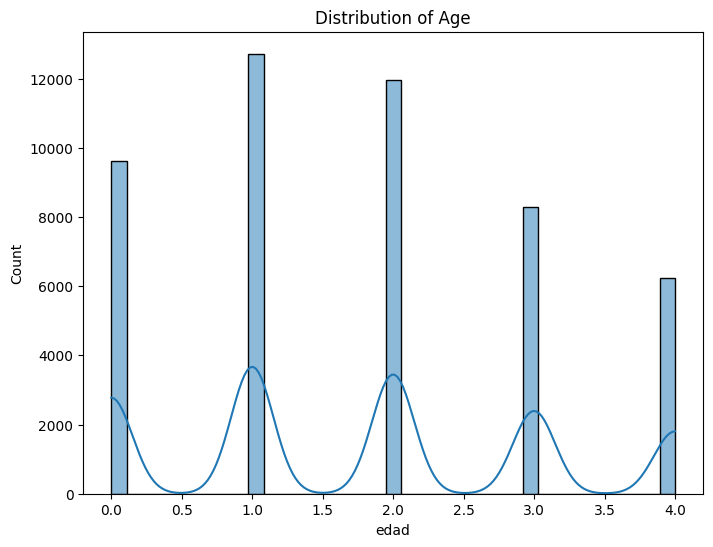

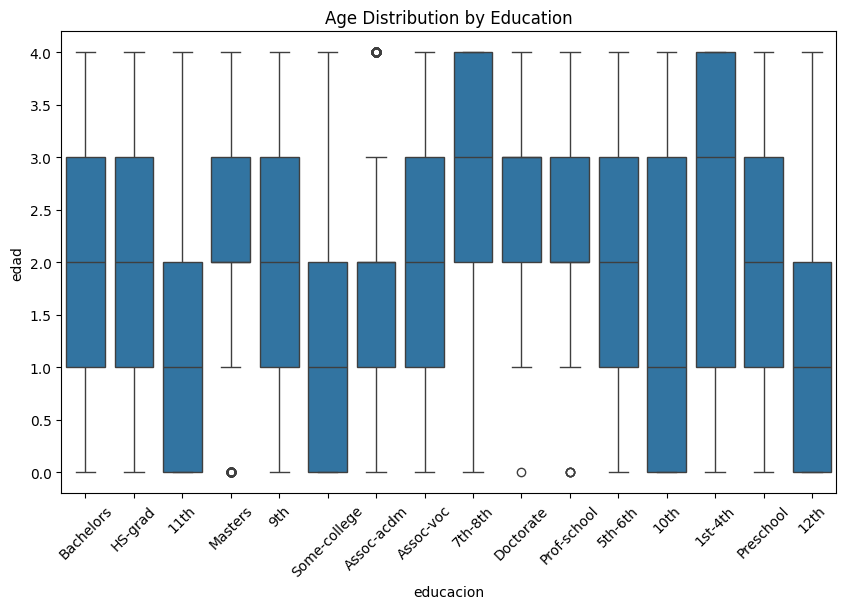

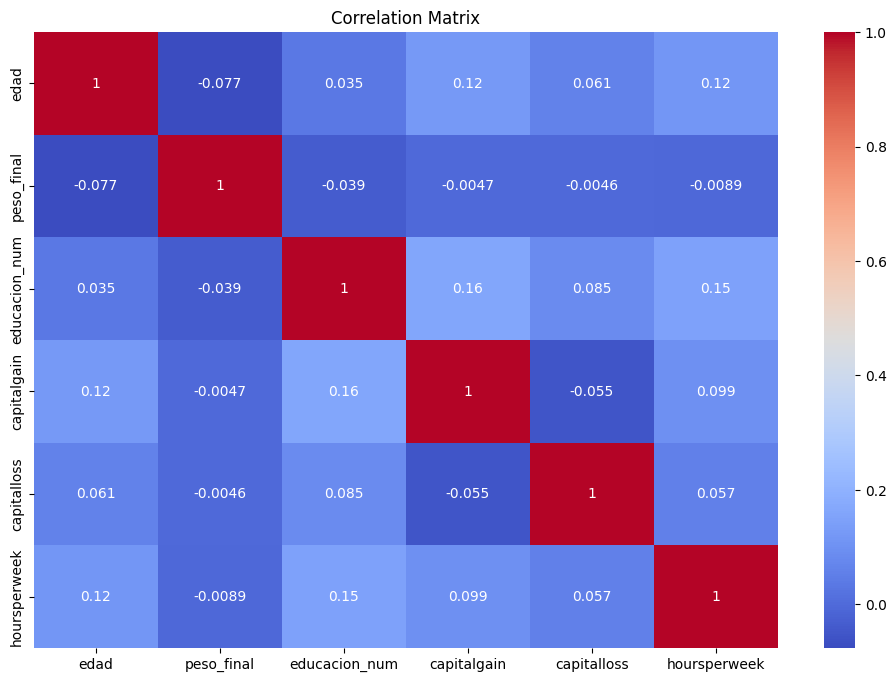

In [15]:
# Display basic information about the DataFrame
print(df.info())

# Summary statistics for numerical features
print(df.describe())

# Check for missing values
print(df.isnull().sum())

# Explore categorical features
for col in df.select_dtypes(include=['object']):
  print(f"\nColumn: {col}")
  print(df[col].value_counts())

# Visualizations (requires matplotlib and seaborn)
import matplotlib.pyplot as plt
import seaborn as sns

# Example: Histogram of a numerical feature (replace 'age' with your column)
plt.figure(figsize=(8, 6))
sns.histplot(df['edad'], kde=True) # Changed 'age' to 'edad'
plt.title('Distribution of Age')
plt.show()

# Example: Boxplot of a numerical feature by a categorical feature
# (replace 'age', 'education', with your columns)
plt.figure(figsize=(10, 6))
sns.boxplot(x='educacion', y='edad', data=df) # Changed 'education' to 'educacion', 'age' to 'edad'
plt.title('Age Distribution by Education')
plt.xticks(rotation=45)
plt.show()

# Example: Correlation matrix (for numerical features)
# Select only numerical features for correlation calculation
numerical_df = df.select_dtypes(include=['number'])
correlation_matrix = numerical_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


# Add more visualizations and analysis as needed based on your data

#Exploración de Regresion Linel Simple

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ... (previous code) ...


# Feature selection based on correlation (example)
correlation_matrix = numerical_df.corr()
target_variable = 'peso_final'  # Replace with your target variable
correlation_with_target = correlation_matrix[target_variable].abs().sort_values(ascending=False)

# Select top N features (e.g., top 3 most correlated features excluding the target itself)
top_features = correlation_with_target[1:4].index.tolist()

# Prepare the data for regression
X = df[top_features]  # Features
y = df[target_variable] # Target

# Handle potential non-numeric data in selected features (if any)
X = pd.get_dummies(X, drop_first=True) # One-hot encoding for categorical features if present


# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Adjust test_size and random_state as needed


# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Print model coefficients
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


Mean Squared Error: 10927000972.219767
R-squared: 0.003704796313642289
Coefficients: [-6557.57860923 -1584.31353261   936.98040925]
Intercept: 215748.4274777611


#Exploracion del el mejor modelo de predicion adecuado para el dataframe adjunto

In [20]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score

# Define models to compare
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "Support Vector Machine": SVR(),
    "K-Nearest Neighbors": KNeighborsRegressor()
}

# Evaluate each model using cross-validation
results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')  # Use 5-fold cross-validation
    rmse_scores = np.sqrt(-scores) # Calculate RMSE
    results[name] = {
        'mean_rmse': np.mean(rmse_scores),
        'std_rmse': np.std(rmse_scores)
    }

# Find the best model
best_model_name = min(results, key=lambda k: results[k]['mean_rmse'])
print(f"Best model based on average RMSE: {best_model_name}")

# Print all model results
for name, result in results.items():
    print(f"{name}: Mean RMSE = {result['mean_rmse']:.4f}, Std RMSE = {result['std_rmse']:.4f}")


# Train and evaluate the best model (example with the best model found):
best_model = models[best_model_name]
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nResults for the best model ({best_model_name}) on the test set:")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")


Best model based on average RMSE: Gradient Boosting
Linear Regression: Mean RMSE = 105227.0841, Std RMSE = 1005.4636
Decision Tree: Mean RMSE = 105395.4757, Std RMSE = 1066.9718
Random Forest: Mean RMSE = 105365.6102, Std RMSE = 1070.8351
Gradient Boosting: Mean RMSE = 104977.6438, Std RMSE = 989.4210
Support Vector Machine: Mean RMSE = 106204.8603, Std RMSE = 1054.4892
K-Nearest Neighbors: Mean RMSE = 115042.1275, Std RMSE = 3283.3357

Results for the best model (Gradient Boosting) on the test set:
Mean Squared Error: 10871432586.722422
R-squared: 0.008771375523102476
